##  第二题：滤后水浊度 FILT. NTU 的动态滞后分析

第二题要求建立动态数学模型，描述原水指标和操作变量如何影响滤后水浊度 `FILT. NTU`。与第一题不同，本题的目标变量不再是出厂水浊度 `NTU`，而是滤后水浊度 `FILT. NTU`。

根据题目描述，主要候选输入变量包括：

- `R/W NTU`：原水浊度；
- `R/W PH`：原水 pH；
- `ALUM`：明矾/混凝剂投加量；
- `F/RIDE`：矾液/混凝剂投加流量；
- `R/W FLOW`：原水流量。

此外，为了增强对原水状态和运行负荷的刻画，本节也考虑 `R/W CLR`、`RIVER LEVEL` 和由 `R/W PUMP DUTY` 转换得到的 `R/W PUMP COUNT` 作为辅助变量。

由于混凝、沉淀和过滤过程存在明显时间延迟，本节首先进行滞后相关性分析，计算：

$$
corr(x_{t-k}, FILT.NTU_t), \quad k=0,1,\ldots,12
$$

其中每个 lag 对应 2 小时，因此 `lag12` 表示 24 小时前。该分析用于为后续动态模型提供变量时滞参数。

## 1：读取数据和构造时间

In [1]:
# ===============================
# 1. 读取数据与构造 DATETIME
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/problem2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

possible_paths = [
    Path("data/merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("../data/merged.xlsx"),
]

DATA_PATH = None
for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Cannot find merged.xlsx. Please check your data path.")

print("Using data file:", DATA_PATH)

df = pd.read_excel(DATA_PATH)

# DATE
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# TIME
def normalize_time_to_string(x):
    if pd.isna(x):
        return np.nan

    if hasattr(x, "hour") and hasattr(x, "minute"):
        return f"{x.hour:02d}:{x.minute:02d}:00"

    s = str(x).strip()

    if "1900-01-01" in s:
        s = s.replace("1900-01-01", "").strip()

    if s.replace(".0", "").isdigit():
        s = s.replace(".0", "")
        s = s.zfill(4)
        return f"{s[:2]}:{s[2:]}:00"

    t = pd.to_datetime(s, errors="coerce")
    if pd.isna(t):
        return np.nan

    return t.strftime("%H:%M:%S")

df["TIME_STR"] = df["TIME"].apply(normalize_time_to_string)

df["DATETIME"] = pd.to_datetime(
    df["DATE"].dt.strftime("%Y-%m-%d") + " " + df["TIME_STR"],
    errors="coerce"
)

df = df.sort_values("DATETIME").reset_index(drop=True)

print("Data shape:", df.shape)
print("DATETIME missing:", df["DATETIME"].isna().sum())
print("Time range:", df["DATETIME"].min(), "to", df["DATETIME"].max())

df[["DATE", "TIME", "TIME_STR", "DATETIME"]].head(15)

Using data file: ..\data\merged.xlsx
Data shape: (5460, 20)
DATETIME missing: 0
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00


,DATE,TIME,TIME_STR,DATETIME
0,2025-01-01,07:00:00,07:00:00,2025-01-01 07:00:00
1,2025-01-01,09:00:00,09:00:00,2025-01-01 09:00:00
2,2025-01-01,11:00:00,11:00:00,2025-01-01 11:00:00
3,2025-01-01,13:00:00,13:00:00,2025-01-01 13:00:00
4,2025-01-01,15:00:00,15:00:00,2025-01-01 15:00:00
5,2025-01-01,17:00:00,17:00:00,2025-01-01 17:00:00
6,2025-01-01,19:00:00,19:00:00,2025-01-01 19:00:00
7,2025-01-01,21:00:00,21:00:00,2025-01-01 21:00:00
8,2025-01-01,23:00:00,23:00:00,2025-01-01 23:00:00
9,2025-01-02,01:00:00,01:00:00,2025-01-02 01:00:00


### 2. Pump Duty 转换

`R/W PUMP DUTY` 表示原水泵运行状态，例如 `1`、`2`、`1+4`、`2+3` 等。该字段不能直接作为普通数值输入模型，因为 `1+4` 并不表示数值 5，而表示两台泵共同运行。

因此，本节将 `R/W PUMP DUTY` 转换为 `R/W PUMP COUNT`，即原水泵运行台数，用于反映原水输送负荷。

In [2]:
# ===============================
# 2. Pump Duty 转换为 Pump Count
# ===============================

def pump_duty_to_count(x):
    if pd.isna(x):
        return np.nan
    
    s = str(x).strip()
    
    if s == "":
        return np.nan
    
    if s.endswith(".0"):
        s = s.replace(".0", "")
    
    if "+" in s:
        parts = [p.strip() for p in s.split("+") if p.strip() != ""]
        return len(parts)
    
    if s.isdigit():
        return 1
    
    return np.nan


if "R/W PUMP DUTY" in df.columns:
    df["R/W PUMP COUNT"] = df["R/W PUMP DUTY"].apply(pump_duty_to_count)

pump_cols = [c for c in ["R/W PUMP DUTY", "R/W PUMP COUNT"] if c in df.columns]

print("Pump count feature created.")
df[pump_cols].head(20)

Pump count feature created.


,R/W PUMP DUTY,R/W PUMP COUNT
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0
5,1.0,1.0
6,1.0,1.0
7,1.0,1.0
8,1.0,1.0
9,1.0,1.0


### 3. 第二题候选变量选择

第二题的目标变量为滤后水浊度 `FILT. NTU`。候选输入变量主要包括原水水质变量和操作控制变量。

本节不使用出厂水端变量，例如 `NTU`、`CLR`、`CL2`、`T/W FLOW` 等作为主要解释变量，因为它们属于滤后或出厂后的下游指标，直接使用可能造成信息泄漏或因果方向不清。

候选变量包括：

- `R/W NTU`：原水浊度；
- `R/W PH`：原水 pH；
- `R/W FLOW`：原水流量；
- `R/W CLR`：原水色度；
- `ALUM`：混凝剂投加量；
- `F/RIDE`：混凝剂投加流量；
- `RIVER LEVEL`：河水水位；
- `R/W PUMP COUNT`：原水泵运行台数。

In [3]:
# ===============================
# 3. 第二题候选变量选择
# ===============================

target = "FILT. NTU"

candidate_features_q2 = [
    "R/W NTU",
    "R/W PH",
    "R/W FLOW",
    "R/W CLR",
    "ALUM",
    "F/RIDE",
    "RIVER LEVEL",
    "R/W PUMP COUNT",
]

candidate_features_q2 = [c for c in candidate_features_q2 if c in df.columns]

# 转换为数值型
for col in candidate_features_q2 + [target]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Target:", target)

print("\nCandidate features for Problem 2:")
for c in candidate_features_q2:
    print("-", c)

print("\nMissing rate of target and candidate features:")
missing_rate_q2 = (
    df[[target] + candidate_features_q2]
    .isna()
    .mean()
    .sort_values(ascending=False) * 100
)

missing_rate_q2

Target: FILT. NTU

Candidate features for Problem 2:
- R/W NTU
- R/W PH
- R/W FLOW
- R/W CLR
- ALUM
- F/RIDE
- RIVER LEVEL
- R/W PUMP COUNT

Missing rate of target and candidate features:


R/W PUMP COUNT    31.648352
ALUM              30.109890
R/W PH            30.109890
FILT. NTU          0.000000
R/W NTU            0.000000
R/W CLR            0.000000
R/W FLOW           0.000000
F/RIDE             0.000000
RIVER LEVEL        0.000000
dtype: float64

### 4. FILT. NTU 的滞后相关性计算

本节计算每个候选变量在 `lag0` 至 `lag12` 下与当前滤后水浊度 `FILT. NTU` 的相关性。

计算形式为：

$$
corr(x_{t-k}, FILT.NTU_t), \quad k=0,1,\ldots,12
$$

其中，`lag1` 表示 2 小时前，`lag12` 表示 24 小时前。

本节同时计算 Pearson 和 Spearman 相关系数。Pearson 用于衡量线性关系，Spearman 用于衡量单调关系。所有结果保存为 `problem2_lag_correlation_all.csv`。

In [4]:
# ===============================
# 4. FILT. NTU 滞后相关性计算
# ===============================

max_lag = 12
min_valid_n = 100

records = []

for feature in candidate_features_q2:
    for lag in range(0, max_lag + 1):
        x_lagged = df[feature].shift(lag)
        y = df[target]
        
        temp = pd.DataFrame({
            "x": x_lagged,
            "y": y
        }).dropna()
        
        n = len(temp)
        
        if n < min_valid_n:
            pearson_corr = np.nan
            spearman_corr = np.nan
        else:
            pearson_corr = temp["x"].corr(temp["y"], method="pearson")
            spearman_corr = temp["x"].corr(temp["y"], method="spearman")
        
        records.append({
            "feature": feature,
            "lag": lag,
            "lag_hours": lag * 2,
            "valid_n": n,
            "pearson_corr": pearson_corr,
            "pearson_abs": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
            "spearman_corr": spearman_corr,
            "spearman_abs": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
        })

q2_lag_corr_df = pd.DataFrame(records)

lag_corr_path = OUTPUT_DIR / "problem2_lag_correlation_all.csv"
q2_lag_corr_df.to_csv(lag_corr_path, index=False, encoding="utf-8-sig")

print("Saved:", lag_corr_path)
q2_lag_corr_df.head(20)

Saved: outputs\problem2\problem2_lag_correlation_all.csv


d:\anaconda\envs\apmcm\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\anaconda\envs\apmcm\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\anaconda\envs\apmcm\lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
d:\anaconda\envs\apmcm\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\anaconda\envs\apmcm\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\anaconda\envs\apmcm\lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0

,feature,lag,lag_hours,valid_n,pearson_corr,pearson_abs,spearman_corr,spearman_abs
0,R/W NTU,0,0,5460,0.169326,0.169326,0.076727,0.076727
1,R/W NTU,1,2,5459,0.169196,0.169196,0.080346,0.080346
2,R/W NTU,2,4,5458,0.164526,0.164526,0.084844,0.084844
3,R/W NTU,3,6,5457,0.159793,0.159793,0.087065,0.087065
4,R/W NTU,4,8,5456,0.157939,0.157939,0.089403,0.089403
5,R/W NTU,5,10,5455,0.155899,0.155899,0.090936,0.090936
6,R/W NTU,6,12,5454,0.153575,0.153575,0.092381,0.092381
7,R/W NTU,7,14,5453,0.151549,0.151549,0.094082,0.094082
8,R/W NTU,8,16,5452,0.148869,0.148869,0.094810,0.094810
9,R/W NTU,9,18,5451,0.147160,0.147160,0.094686,0.094686


### 5. 第二题候选时滞参数筛选

在得到所有候选变量的滞后相关性后，本节分别按照 Pearson 和 Spearman 相关系数的绝对值，为每个变量选取相关性最强的滞后阶数。

数学形式为：

$$
\tau_i=\underset{k \in \{0,1,\ldots,12\}}{\arg\max}\ |\rho_i(k)|
$$

其中，$\tau_i$ 表示变量 $x_i$ 的候选最优滞后阶数，$\rho_i(k)$ 表示变量 $x_i$ 在第 $k$ 阶滞后下与当前 `FILT. NTU` 的相关系数。

需要注意的是，数学最优滞后阶数只是候选结果，后续仍需要结合水处理机理、变量缺失情况和物理合理性进行筛选。

In [5]:
# ===============================
# 5. 第二题候选时滞参数筛选
# ===============================

best_pearson_q2 = (
    q2_lag_corr_df
    .dropna(subset=["pearson_abs"])
    .sort_values(["feature", "pearson_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_pearson_q2 = best_pearson_q2[
    ["feature", "lag", "lag_hours", "valid_n", "pearson_corr", "pearson_abs"]
].rename(columns={
    "lag": "best_lag_pearson",
    "lag_hours": "best_lag_hours_pearson",
    "valid_n": "valid_n_pearson"
})

best_spearman_q2 = (
    q2_lag_corr_df
    .dropna(subset=["spearman_abs"])
    .sort_values(["feature", "spearman_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_spearman_q2 = best_spearman_q2[
    ["feature", "lag", "lag_hours", "valid_n", "spearman_corr", "spearman_abs"]
].rename(columns={
    "lag": "best_lag_spearman",
    "lag_hours": "best_lag_hours_spearman",
    "valid_n": "valid_n_spearman"
})

q2_best_lag_summary = pd.merge(
    best_pearson_q2,
    best_spearman_q2,
    on="feature",
    how="outer"
)

best_lag_path = OUTPUT_DIR / "problem2_best_lag_summary.csv"
q2_best_lag_summary.to_csv(best_lag_path, index=False, encoding="utf-8-sig")

print("Saved:", best_lag_path)
q2_best_lag_summary

Saved: outputs\problem2\problem2_best_lag_summary.csv


,feature,best_lag_pearson,best_lag_hours_pearson,valid_n_pearson,pearson_corr,pearson_abs,best_lag_spearman,best_lag_hours_spearman,valid_n_spearman,spearman_corr,spearman_abs
0,ALUM,4,8,3812,-0.038782,0.038782,12,24,3804,0.078543,0.078543
1,F/RIDE,5,10,5455,-0.015226,0.015226,0,0,5460,-0.083111,0.083111
2,R/W CLR,0,0,5460,0.148763,0.148763,7,14,5453,0.074123,0.074123
3,R/W FLOW,1,2,5459,0.084751,0.084751,12,24,5448,0.056888,0.056888
4,R/W NTU,0,0,5460,0.169326,0.169326,12,24,5448,0.097893,0.097893
5,R/W PH,8,16,3808,-0.019659,0.019659,7,14,3809,0.014850,0.014850
6,RIVER LEVEL,12,24,5448,0.195139,0.195139,8,16,5452,0.184250,0.184250


### 6. 核心变量滞后相关性曲线

为了更直观地观察不同变量对 `FILT. NTU` 的滞后影响，本节绘制核心变量在不同滞后时间下的 Pearson 相关性曲线。

若某变量在短滞后下相关性较强，说明其影响可能集中在当前或前几个采样时刻；若某变量在较长滞后下出现相关性峰值，则需要结合混凝沉淀过滤过程判断该时滞是否具有物理意义。

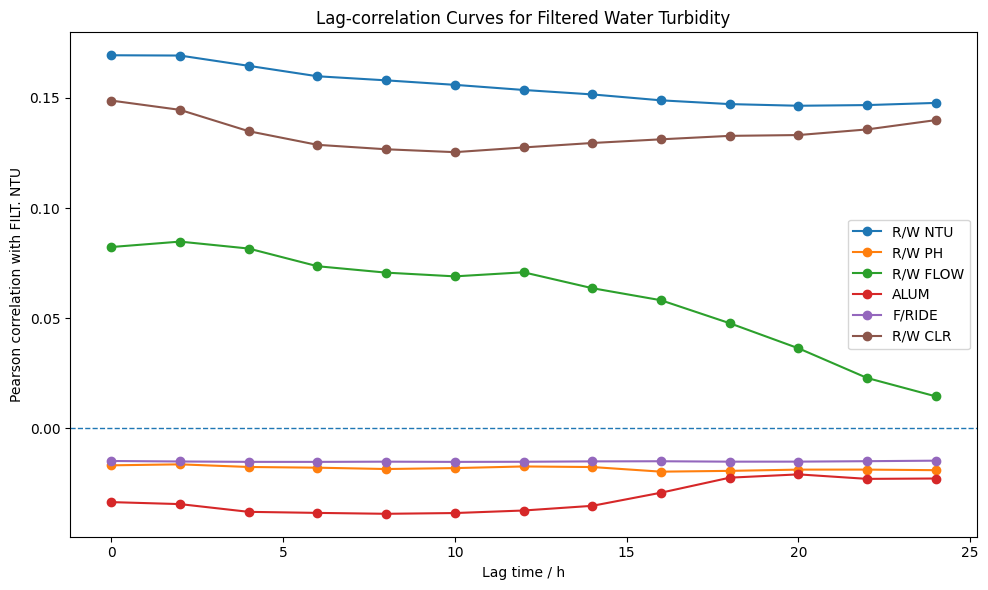

Saved: outputs\problem2\problem2_lag_correlation_curves_key_features.png


In [6]:
# ===============================
# 6. 核心变量滞后相关性曲线
# ===============================

selected_plot_features_q2 = [
    "R/W NTU",
    "R/W PH",
    "R/W FLOW",
    "ALUM",
    "F/RIDE",
    "R/W CLR",
]

selected_plot_features_q2 = [
    f for f in selected_plot_features_q2 if f in candidate_features_q2
]

plt.figure(figsize=(10, 6))

for feature in selected_plot_features_q2:
    temp = q2_lag_corr_df[q2_lag_corr_df["feature"] == feature]
    plt.plot(
        temp["lag_hours"],
        temp["pearson_corr"],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag time / h")
plt.ylabel("Pearson correlation with FILT. NTU")
plt.title("Lag-correlation Curves for Filtered Water Turbidity")
plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / "problem2_lag_correlation_curves_key_features.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

### 7. 第二题滞后相关性热力图

热力图用于整体展示所有候选变量在不同滞后时间下与 `FILT. NTU` 的 Pearson 相关性。

该图可以帮助判断哪些变量存在较明显的时滞响应，也可以辅助选择后续动态模型中的 selected-lag 特征。

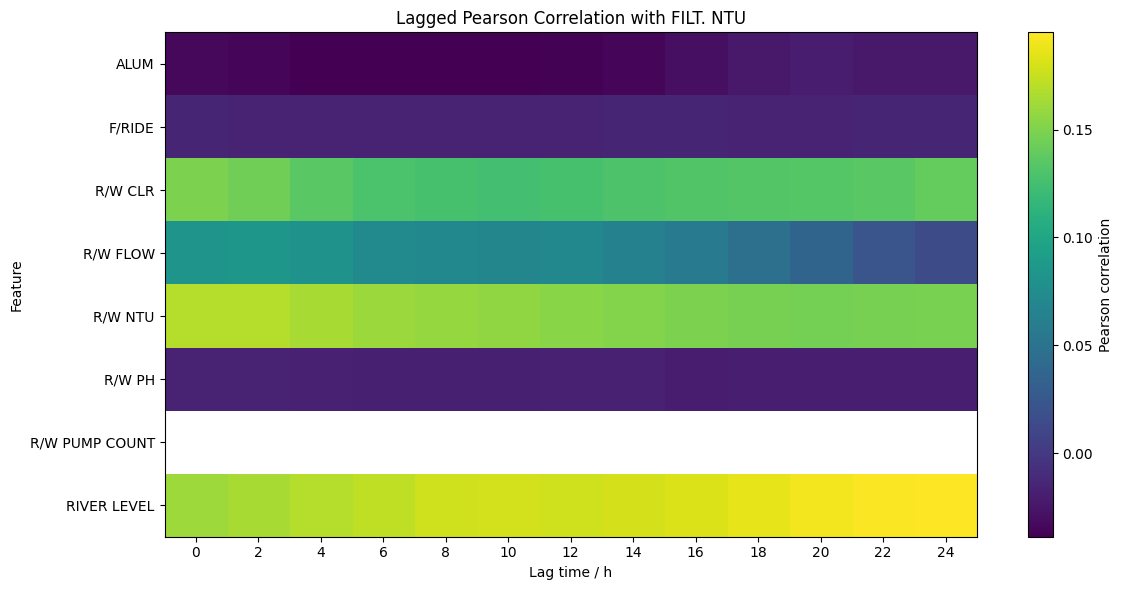

Saved: outputs\problem2\problem2_lag_pearson_heatmap.png


In [7]:
# ===============================
# 7. 第二题滞后相关性热力图
# ===============================

heatmap_data_q2 = q2_lag_corr_df.pivot(
    index="feature",
    columns="lag_hours",
    values="pearson_corr"
)

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data_q2, aspect="auto")
plt.colorbar(label="Pearson correlation")

plt.xticks(
    ticks=np.arange(len(heatmap_data_q2.columns)),
    labels=heatmap_data_q2.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_data_q2.index)),
    labels=heatmap_data_q2.index
)

plt.xlabel("Lag time / h")
plt.ylabel("Feature")
plt.title("Lagged Pearson Correlation with FILT. NTU")

plt.tight_layout()

heatmap_path = OUTPUT_DIR / "problem2_lag_pearson_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

print("Saved:", heatmap_path)